In [1]:
import numpy as np 

import h5py
from tqdm import tqdm

from astropy.table import Table

import pandas as pd

import matplotlib.pyplot as plt 

In [2]:
def import_hydro(file_number, directory):
    """Reads in data in the form of h5py files from TNG100
    Args:
        file_number: the desired number of files to be read in
        directory: string that details path from location 
        of notebook to dataset, i.e. 'Data/hydro_data'
    Return:
        Outputs an astropy table with 'ID', 'SubhaloMass', 
        'SubhaloFlag','StellarMass', 'x', 'y', 'z',
        'logSubhaloMass' and 'logStellarMass' as keys
    Note:
        'StellarMass' units Msun/h
        'logStellarMass' = log10('StellarMass')
    """
    subhalo_ids = []
    subhalo_mass = []
    subhalo_flag = []
    stellar_mass = []
    x_position = []
    y_position = []
    z_position = []
    count = 0
    
    for ii in tqdm(range(0, file_number + 1)):
        filename = f'{directory}/fof_subhalo_tab_099.{ii}.hdf5' 
        with h5py.File(filename, 'r') as f:
            if 'SubhaloMass' in f['Subhalo'].keys(): 
                for s in f['Subhalo']['SubhaloMass']:
                    subhalo_mass.append(s)
                    subhalo_ids.append(count)
                    count+=1
                for flag in f['Subhalo']['SubhaloFlag']:
                    subhalo_flag.append(flag)
                for star in f['Subhalo']['SubhaloMassInRadType'][:,4]: 
                    stellar_mass.append(star)
                for (x, y, z) in f['Subhalo']['SubhaloPos'][:]:
                    x_position.append(x)
                    y_position.append(y)
                    z_position.append(z) 
                             
    t = Table(data = [subhalo_ids, subhalo_mass, subhalo_flag, stellar_mass, 
                      x_position, y_position, z_position], 
              names = ['subfind_id', 'SubhaloMass', 'SubhaloFlag', 'StellarMass', 'x', 'y', 'z'])


    # Convert from TNG units to Msun/h
    t['StellarMass'] = t['StellarMass']*1e10 
    t['SubhaloMass'] = t['SubhaloMass']*1e10 

    # Create logSubhaloMass and logStellarMass 
    t['logSubhaloMass'] = np.log10(t['SubhaloMass'])
    t['logStellarMass'] = np.log10(t['StellarMass'])
    
    # convert from ckpc/h to cMpc/h
    t['x'] = t['x'] / 1000
    t['y'] = t['y'] / 1000
    t['z'] = t['z'] / 1000
    return t

In [3]:
def import_color(directory):
    """Reads in color data from a given directory
    Args:
        directory: string that details path from location
    Return:
        Outputs pandas data fram with columns "sdss_u",
        "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wfc_acs_f606w", 
        "des_y", "jwst_f150w", and "subfind_id"

    Note: Use to compute "g - i" for red/blue galaxies
    """
    filename = f'{directory}/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5' 
    f = h5py.File(filename, "r")
    colnames = (
        "sdss_u",
        "sdss_g",
        "sdss_r",
        "sdss_i",
        "sdss_z",
        "wfc_acs_f606w",
        "des_y",
        "jwst_f150w",
    )
    arr = f["Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc"][:]
    arr = np.mean(arr, axis=-1) # averaging over projections
    df_color = pd.DataFrame(arr, columns=colnames)
    df_color["subfind_id"] = f["subhaloIDs"]
    return df_color

In [4]:
hydro_raw = import_hydro(447, "../../data/tng100") # need to apply subhalo flag later

100%|██████████| 448/448 [01:39<00:00,  4.49it/s]
/tmp/ipykernel_24142/2533459153.py:52: RuntimeWarning: divide by zero encountered in log10
  t['logStellarMass'] = np.log10(t['StellarMass'])


In [5]:
# import color
color_table = import_color("../../data")

In [6]:
len(hydro_raw), len(color_table)

(4371211, 4371211)

In [7]:
# they match exactly and ids too
np.all(hydro_raw['subfind_id'] == color_table['subfind_id'])

np.True_

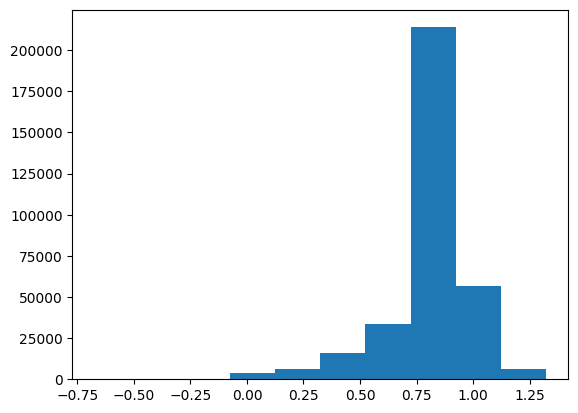

In [8]:
# so we just 
hydro_raw['color'] = color_table['sdss_g'] - color_table['sdss_i']
plt.hist(hydro_raw['color']);

In [9]:
# appply subhalo flag 
subhalo_flag_mask = hydro_raw['SubhaloFlag'] == 1 
hydro_full = hydro_raw[subhalo_flag_mask]
len(hydro_full)

4361030

In [10]:
# now need to match with phil's data 
tree_data = np.load("../../data/out-trees-tng100-bar.npz")
tree_data['subfind_id'].shape

(101431,)

In [17]:
id_mask = np.isin(hydro_full['subfind_id'], tree_data['subfind_id'])
hydro_final = hydro_full[id_mask]
len(hydro_final)

101364

In [20]:
# sort by subfind_id
hydro_final.sort(keys=('subfind_id'))
assert np.all(np.sort(hydro_final['subfind_id'])== hydro_final['subfind_id'])

In [24]:
for k in tree_data:
    print(k)

subfind_id
vpeak
mpeak_mah
is_sub
a12
mpeak_pre
mpeak
stellar_mass


In [ ]:
id_mask2 = np.isin(tree_data['subfind_id'], hydro_final['subfind_id']) # TODO: why do we need this? 

sort_mask = np.argsort(tree_data['subfind_id'][id_mask2])

for k in tree_data:
    if k not in ("subfind_id", ):
        arr = tree_data[k][id_mask2][sort_mask]
        hydro_final[k] = arr 




In [35]:
len(hydro_final)

101364

In [26]:

hydro_final.keys()

['subfind_id',
 'SubhaloMass',
 'SubhaloFlag',
 'StellarMass',
 'x',
 'y',
 'z',
 'logSubhaloMass',
 'logStellarMass',
 'color',
 'vpeak',
 'mpeak_mah',
 'is_sub',
 'a12',
 'mpeak_pre',
 'mpeak',
 'stellar_mass']

In [ ]:
assert np.all(hydro_final['StellarMass'] == hydro_final['stellar_mass']) # sanityy check

(array([   2.,    6.,   15.,   30.,   94.,  239.,  450.,  797., 1164.,
        1490., 1490., 1223.,  822.,  562.,  395.,  290.,  404.,  679.,
         815.,  290.,   53.]),
 array([0.07439804, 0.13347271, 0.19254738, 0.25162208, 0.31069672,
        0.36977142, 0.42884609, 0.48792076, 0.5469954 , 0.6060701 ,
        0.6651448 , 0.72421944, 0.78329414, 0.84236878, 0.90144348,
        0.96051812, 1.01959276, 1.07866752, 1.13774216, 1.1968168 ,
        1.25589156, 1.3149662 ]),
 <BarContainer object of 21 artists>)

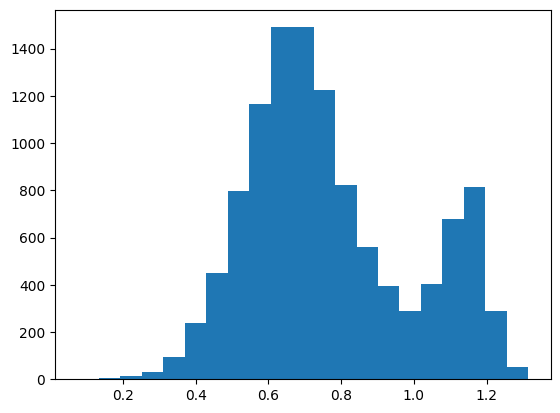

In [29]:
# color distribution is twice as nice
log_mpeak = np.log10(hydro_final['mpeak'])
mask = (log_mpeak > 11 ) & (log_mpeak < 12)

plt.hist(hydro_final['color'][mask], bins=21)


In [36]:
from scipy.stats import spearmanr

spearmanr(hydro_final['color'][mask], hydro_final['a12'][mask])

SignificanceResult(statistic=np.float64(-0.6246417001901717), pvalue=np.float64(0.0))

In [ ]:
# write table to disk
from astropy.io import ascii

ascii.write(hydro_final, output="../../data/hydro_final.ecsv", format='ecsv')